<a href="https://colab.research.google.com/github/AbhijithDuggaraju/DAV/blob/main/Wine_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
np.random.seed(42)
n_samples = 1000
alcohol = np.random.normal(10, 2, n_samples)
pH = np.random.normal(3.2, 0.5, n_samples)
citric_acid = np.random.normal(0.5, 0.2, n_samples)
fixed_acidity = np.random.normal(7, 1.5, n_samples)
volatile_acidity = np.random.normal(0.3, 0.1, n_samples)
quality = np.random.randint(3, 9, n_samples)
df = pd.DataFrame({
    'alcohol': alcohol,
    'pH': pH,
    'citric acid': citric_acid,
    'fixed acidity': fixed_acidity,
    'volatile acidity': volatile_acidity,
    'quality': quality
})
print(df.head())


     alcohol        pH  citric acid  fixed acidity  volatile acidity  quality
0  10.993428  3.899678     0.364964       4.138289          0.213651        3
1   9.723471  3.662317     0.471096       5.709422          0.296880        8
2  11.295377  3.229815     0.341516       6.379592          0.301802        6
3  13.046060  2.876532     0.438408       9.831531          0.347263        7
4   9.531693  3.549112     0.121277       7.834830          0.163314        8


In [9]:

print("Missing values in each column:\n", df.isnull().sum())
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())
print("Missing values handled successfully!")



Missing values in each column:
 alcohol             0
pH                  0
citric acid         0
fixed acidity       0
volatile acidity    0
quality             0
dtype: int64
Missing values handled successfully!


In [10]:

print("Statistical summary:\n", df.describe())
wine_quality = df['quality']
print("Mean Wine Quality:", np.mean(wine_quality))
print("Median Wine Quality:", np.median(wine_quality))
print("Standard Deviation of Wine Quality:", np.std(wine_quality))



Statistical summary:
            alcohol           pH  citric acid  fixed acidity  volatile acidity  \
count  1000.000000  1000.000000  1000.000000    1000.000000       1000.000000   
mean     10.038664     3.235418     0.501167       6.971921          0.295073   
std       1.958432     0.498727     0.196691       1.540699          0.099238   
min       3.517465     1.729806    -0.103902       2.605827         -0.017670   
25%       8.704819     2.896879     0.370400       5.893869          0.231740   
50%      10.050601     3.231539     0.499950       7.000277          0.298176   
75%      11.295888     3.564441     0.632183       8.000418          0.363912   
max      17.705463     4.796554     1.285248      11.864639          0.611291   

           quality  
count  1000.000000  
mean      5.469000  
std       1.743008  
min       3.000000  
25%       4.000000  
50%       5.000000  
75%       7.000000  
max       8.000000  
Mean Wine Quality: 5.469
Median Wine Quality: 5.0
Standard 

<ipython-input-11-9350a0404552>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='coolwarm')


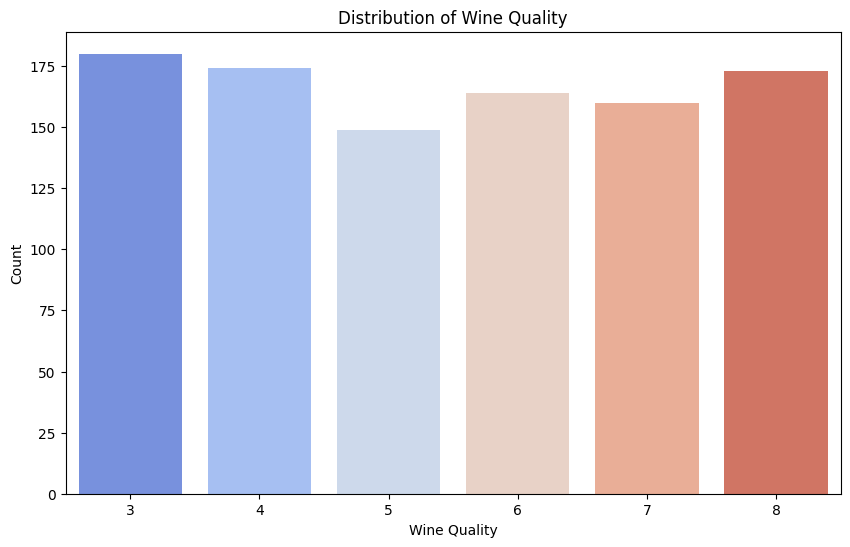

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=df, palette='coolwarm')
plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.show()


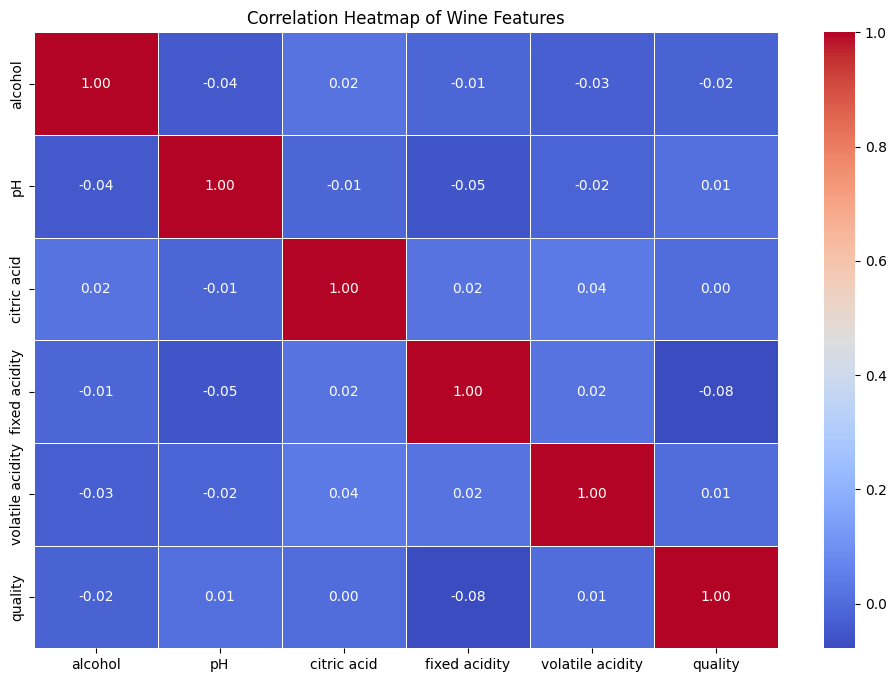

In [12]:

df_numeric = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Wine Features")
plt.show()


Top 10 features correlated with wine quality:
 pH                  0.013582
volatile acidity    0.005366
citric acid         0.004322
alcohol            -0.022337
fixed acidity      -0.077925
dtype: float64


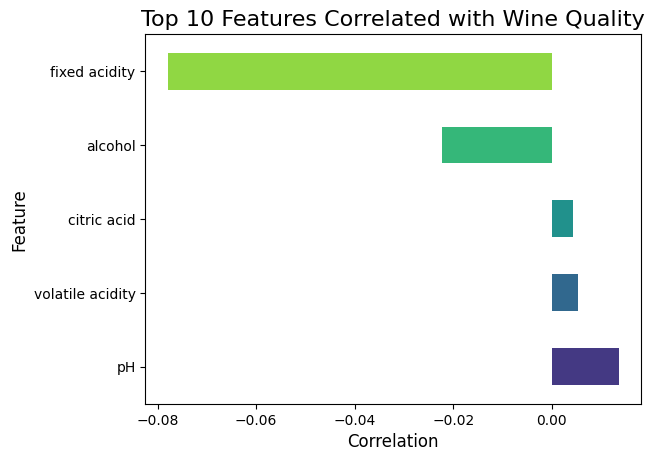

In [13]:

quality_corr = df.drop('quality', axis=1).corrwith(df['quality']).sort_values(ascending=False)
print("Top 10 features correlated with wine quality:\n", quality_corr.head(10))
quality_corr.head(10).plot(kind='barh', color=sns.color_palette("viridis", len(quality_corr.head(10))))
plt.title('Top 10 Features Correlated with Wine Quality', fontsize=16)
plt.xlabel('Correlation', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()


<ipython-input-14-2ea6344ef385>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df, palette='coolwarm')


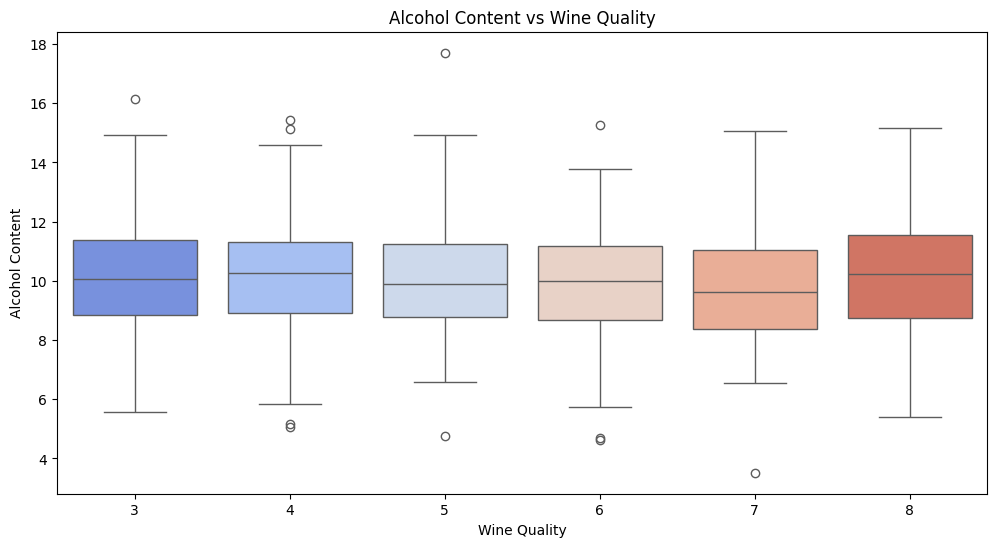

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='quality', y='alcohol', data=df, palette='coolwarm')
plt.title("Alcohol Content vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol Content")
plt.show()


<ipython-input-15-8fd5a3f0724d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='pH', data=df, palette='coolwarm')


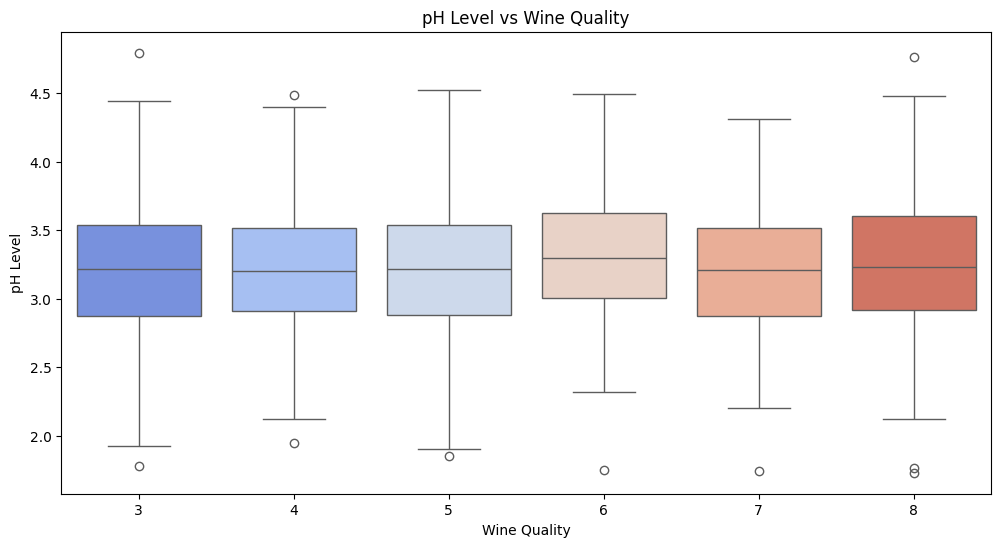

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='quality', y='pH', data=df, palette='coolwarm')
plt.title("pH Level vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("pH Level")
plt.show()


<ipython-input-16-490ebec46781>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='citric acid', data=df, palette='coolwarm')


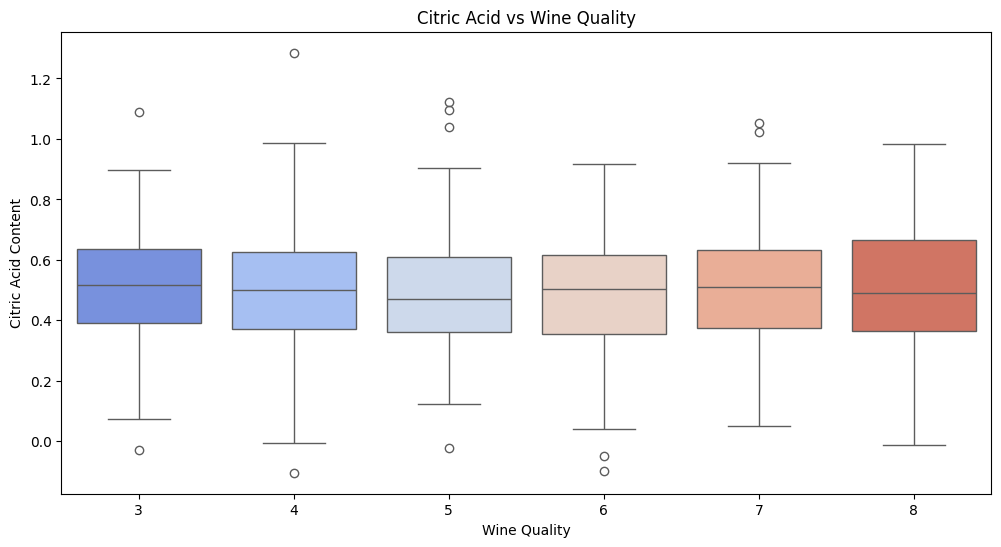

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='quality', y='citric acid', data=df, palette='coolwarm')
plt.title("Citric Acid vs Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Citric Acid Content")
plt.show()


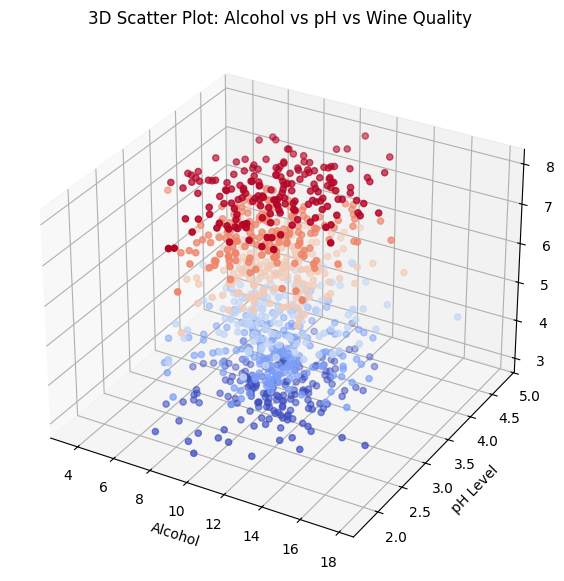

In [17]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['alcohol'], df['pH'], df['quality'], c=df['quality'], cmap='coolwarm', marker='o')
ax.set_xlabel('Alcohol')
ax.set_ylabel('pH Level')
ax.set_zlabel('Wine Quality')
plt.title("3D Scatter Plot: Alcohol vs pH vs Wine Quality")
plt.show()


In [18]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(df['alcohol'], df['quality'])
print(f"Pearson correlation between alcohol and quality: {corr:.2f}")
print(f"P-value: {p_value:.4f}")


Pearson correlation between alcohol and quality: -0.02
P-value: 0.4805
